<a href="https://colab.research.google.com/github/danyal110/Insurance-claim-prediction/blob/main/InsuranceClaim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Ingest

In [111]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [112]:
df=pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [114]:
num_var=['age','bmi','children','charges']
cat_var=['sex','smoker','region']



In [115]:
df.shape

(1338, 7)

In [116]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [117]:
df["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [118]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## EDA

Text(0.5, 1.0, 'Age Vs Charges')

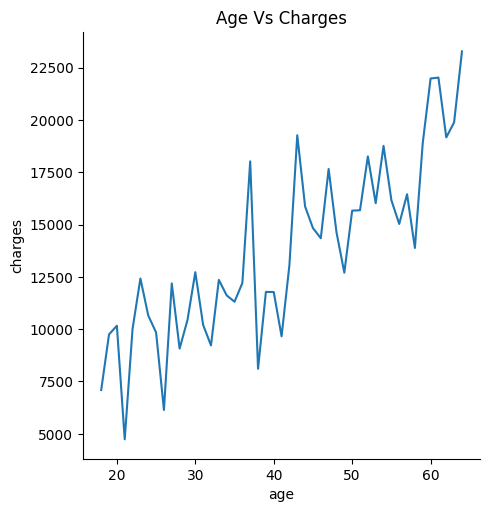

In [119]:
# Age vs Charges
# the more the age the more will be insurance charge (roughly estimated)
sns.relplot(data=df, x="age", y="charges", kind="line",errorbar=None)
plt.title("Age Vs Charges")

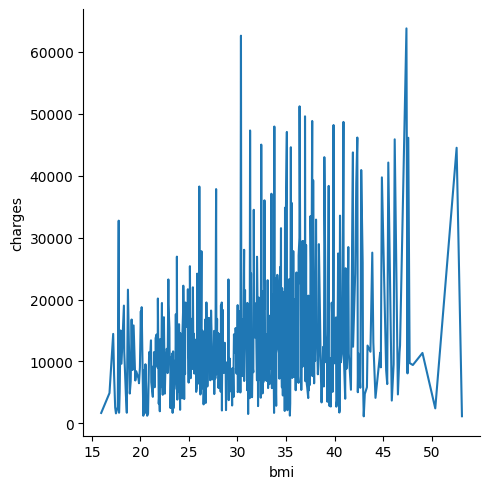

In [120]:
sns.relplot(data=df, x="bmi", y="charges", kind="line",errorbar=None)

Text(0.5, 1.0, 'sex vs charges')

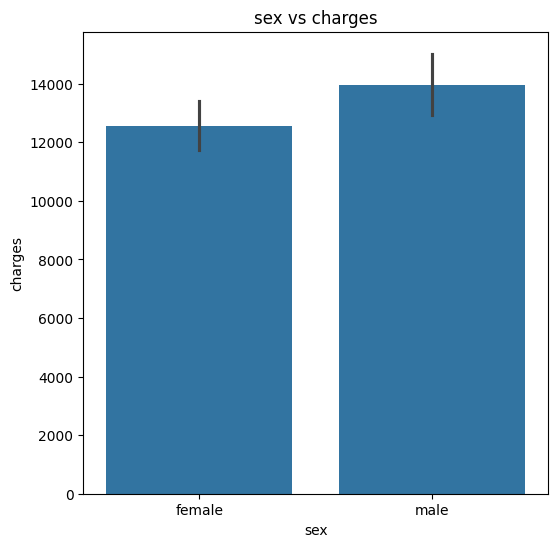

In [121]:
#males have slightly greater charges than females
plt.figure(figsize = (6, 6))
sns.barplot(x = 'sex', y = 'charges', data = df)

plt.title('sex vs charges')

Text(0.5, 1.0, 'region vs charges')

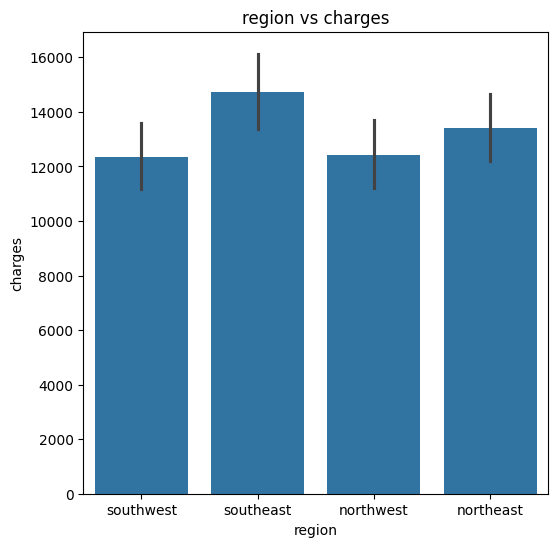

In [122]:
#region does not play much role in determining charges
plt.figure(figsize = (6, 6))
sns.barplot(x = 'region', y = 'charges', data = df)

plt.title('region vs charges')

Text(0.5, 1.0, 'smoker vs charges')

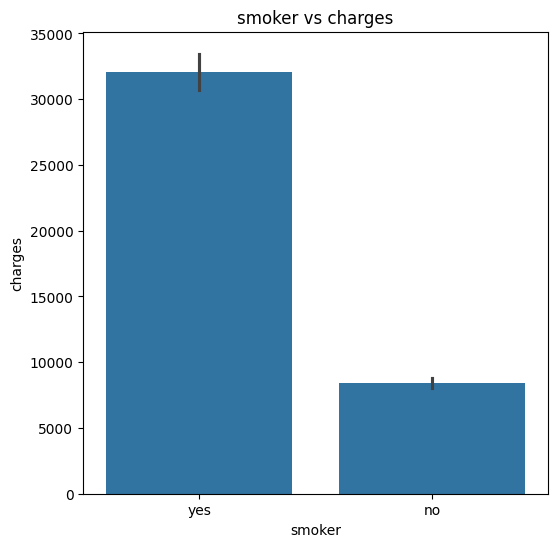

In [123]:
#smoker vs charges
# from the graph below, it is visible that smokers have more insurance charges than the non smokers

plt.figure(figsize = (6, 6))
sns.barplot(x = 'smoker', y = 'charges', data = df)

plt.title('smoker vs charges')

Text(0.5, 1.0, 'children vs charges')

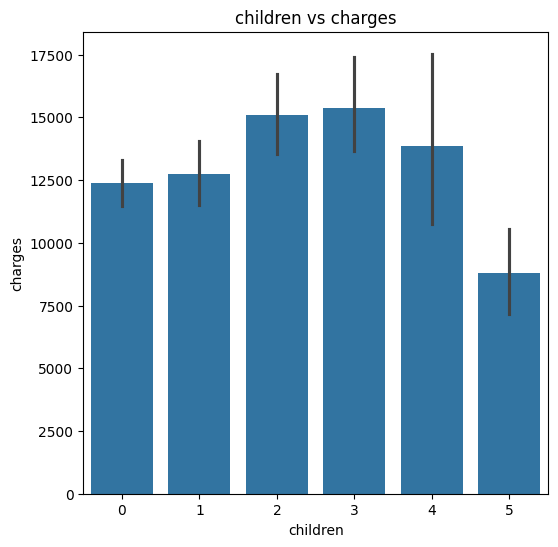

In [124]:
plt.figure(figsize = (6, 6))
sns.barplot(x = 'children', y = 'charges', data = df)

plt.title('children vs charges')

<Axes: >

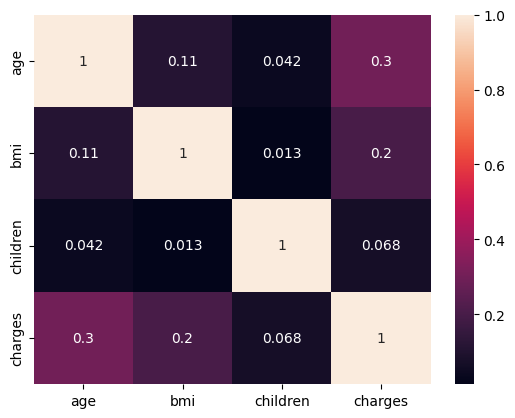

In [125]:
#Correlation bt continuous varibles with insurance charges
x=df[num_var].corr()
sns.heatmap(x,annot=True)

In [126]:
# Correlation bt smoker and charges
from scipy.stats import pointbiserialr

smoker_num = df['smoker'].map({'yes': 1, 'no': 0})

corr, p_value = pointbiserialr(
    smoker_num,
    df['charges']
)

print("Correlation:", corr)
print("p-value:", p_value)

Correlation: 0.7872514304984773
p-value: 8.271435842177446e-283


In [127]:
# Correlation bt smoker and charges
from scipy.stats import pointbiserialr

gender_num = df['sex'].map({'male': 1, 'female': 0})

corr, p_value = pointbiserialr(
    gender_num,
    df['charges']
)

print("Correlation:", corr)
print("p-value:", p_value)

Correlation: 0.05729206220202537
p-value: 0.036132721005929666


In [128]:

import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('charges ~ C(region)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

eta_squared = anova_table.loc['C(region)', 'sum_sq'] / anova_table['sum_sq'].sum()

print("Eta squared:", eta_squared)

                 sum_sq      df         F    PR(>F)
C(region)  1.300760e+09     3.0  2.969627  0.030893
Residual   1.947735e+11  1334.0       NaN       NaN
Eta squared: 0.006634016807031255


In [129]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df['charges'],
    groups=df['region'],
    alpha=0.05
)

print(tukey)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
  group1    group2   meandiff  p-adj    lower      upper   reject
-----------------------------------------------------------------
northeast northwest  -988.8091 0.7245 -3428.9343 1451.3161  False
northeast southeast  1329.0269 0.4745 -1044.9417 3702.9955  False
northeast southwest -1059.4471 0.6792 -3499.5723 1380.6781  False
northwest southeast  2317.8361 0.0583   -54.1994 4689.8716  False
northwest southwest    -70.638 0.9999 -2508.8826 2367.6066  False
southeast southwest -2388.4741 0.0477 -4760.5096  -16.4386   True
-----------------------------------------------------------------


In [130]:
#ANOVA indicated a statistically significant difference in charges across regions(F = 2.97, p = 0.031).
#However, the effect size was very small (η² = 0.0066), indicating that region explained
# approximately 0.66% of the variance in charges.

In [131]:
#Dropping region
df.drop(["region"],axis=1,inplace=True)

In [132]:
df.head()

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


In [133]:
#one-hot encoding

df=pd.get_dummies(df,columns=["sex","smoker"],drop_first=True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,False,True
1,18,33.770,1,1725.55230,True,False
2,28,33.000,3,4449.46200,True,False
3,33,22.705,0,21984.47061,True,False
4,32,28.880,0,3866.85520,True,False


In [134]:
from sklearn.model_selection import train_test_split
X=df.drop("charges",axis=1)
y=df["charges"]

In [135]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)


## Modelling


In [136]:

X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [137]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [138]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
rmse = np.sqrt(mse)
print("RMSE :", rmse)
print(f"R-squared Score: {r2:.4f}")

Mean Squared Error: 33979257.0508
RMSE : 5829.172930254189
R-squared Score: 0.7811


In [139]:
y_test[:5]

,charges
764,9095.06825
887,5272.17580
890,29330.98315
1293,9301.89355
259,33750.29180


In [140]:
y_pred[:5]

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081])

In [141]:
from sklearn.svm import SVR

svr=SVR()
svr.fit(X_train,y_train)

SVR()

In [142]:

# Make predictions on the test set
y_pred = svr.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
rmse = np.sqrt(mse)
print("RMSE :", rmse)
print(f"R-squared Score: {r2:.4f}")

Mean Squared Error: 165650840.7343
RMSE : 12870.54158667464
R-squared Score: -0.0670


In [143]:
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor()
rf.fit(X_train,y_train)

RandomForestRegressor()

In [144]:

# Make predictions on the test set
y_pred = rf.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
rmse = np.sqrt(mse)
print("RMSE :", rmse)
print(f"R-squared Score: {r2:.4f}")

Mean Squared Error: 22594053.0204
RMSE : 4753.320210173315
R-squared Score: 0.8545


In [146]:
from xgboost import XGBRegressor

xgb=XGBRegressor()
xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [147]:

# Make predictions on the test set
y_pred = xgb.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
rmse = np.sqrt(mse)
print("RMSE :", rmse)
print(f"R-squared Score: {r2:.4f}")

Mean Squared Error: 24317286.2099
RMSE : 4931.256047894378
R-squared Score: 0.8434
